In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/data/processed/master_topics.csv",
    low_memory=False
)
df = df[df['topic_label'] != 'Insufficient Text'].copy()
print(f"Loaded {len(df):,} reviews with topics and sentiment")

Loaded 108,218 reviews with topics and sentiment


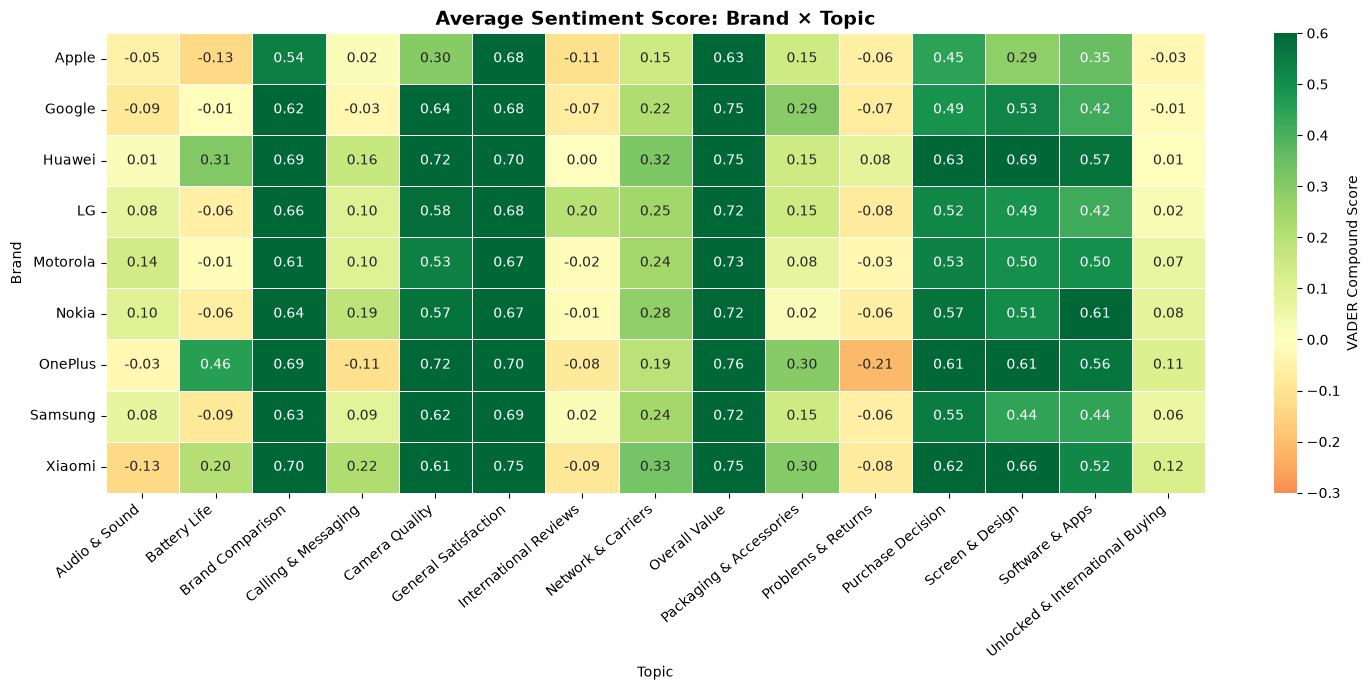

In [2]:
pivot = df.groupby(['brand', 'topic_label'])['vader_compound'].mean().unstack()

plt.figure(figsize=(15, 7))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-0.3,
    vmax=0.6,
    linewidths=0.5,
    cbar_kws={'label': 'VADER Compound Score'}
)
plt.title('Average Sentiment Score: Brand × Topic', fontsize=14, fontweight='bold')
plt.xlabel('Topic')
plt.ylabel('Brand')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/05_brand_topic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

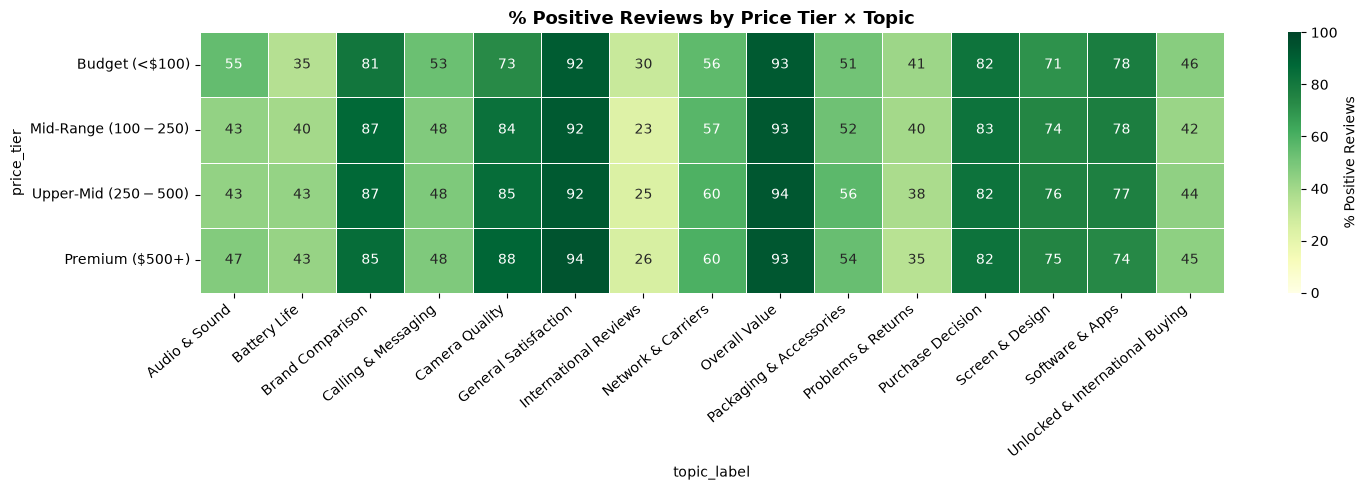

In [3]:
df_priced = df[df['price_tier'] != 'Unknown'].copy()

pivot2 = df_priced.groupby(['price_tier', 'topic_label'])['sentiment'].apply(
    lambda x: (x == 'Positive').mean() * 100
).unstack()

TIER_ORDER = ['Budget (<$100)', 'Mid-Range ($100-$250)', 'Upper-Mid ($250-$500)', 'Premium ($500+)']
pivot2 = pivot2.reindex(TIER_ORDER)

plt.figure(figsize=(15, 5))
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='YlGn', vmin=0, vmax=100,
            linewidths=0.5, cbar_kws={'label': '% Positive Reviews'})
plt.title('% Positive Reviews by Price Tier × Topic', fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/05_price_topic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Voice assistant sentiment:
sentiment         Negative  Neutral  Positive
assistant                                    
Bixby                 28.3      2.3      69.4
Google Assistant      12.3      0.9      86.8
Other Voice           15.3      3.3      81.3
Siri                  14.7      3.1      82.2


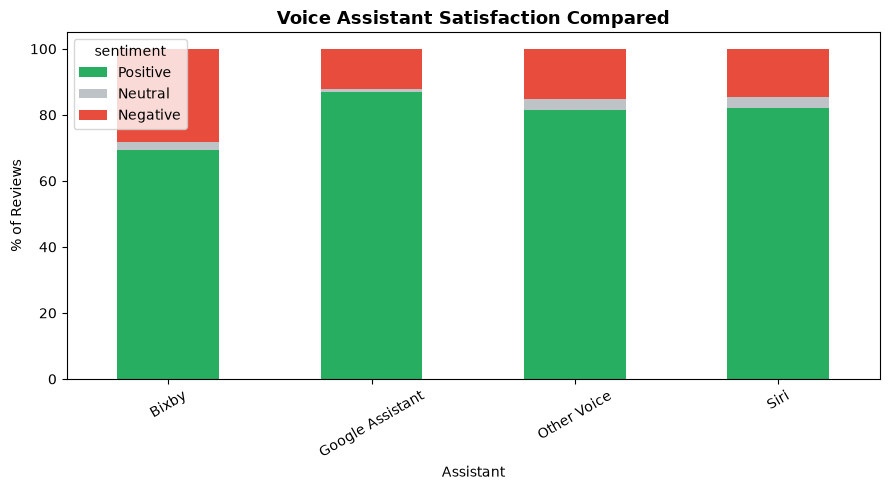

In [4]:
va_df = df[df['mentions_voice_assistant'] == 1].copy()

def label_assistant(text):
    t = str(text).lower()
    if 'google assistant' in t or 'hey google' in t:
        return 'Google Assistant'
    if 'siri' in t or 'hey siri' in t:
        return 'Siri'
    if 'bixby' in t:
        return 'Bixby'
    return 'Other Voice'

va_df['assistant'] = va_df['review_body'].apply(label_assistant)

print("Voice assistant sentiment:")
va_sentiment = va_df.groupby(['assistant', 'sentiment']).size().unstack(fill_value=0)
va_pct = va_sentiment.div(va_sentiment.sum(axis=1), axis=0) * 100
print(va_pct.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
va_pct[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#27ae60', '#bdc3c7', '#e74c3c']
)
ax.set_title('Voice Assistant Satisfaction Compared', fontsize=13, fontweight='bold')
ax.set_xlabel('Assistant')
ax.set_ylabel('% of Reviews')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/05_voice_assistant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Brand loyalty proxy (5-star rate):
          total_reviews  five_star_pct  mean_vader  mean_rating
brand                                                          
Xiaomi             2937          64.73        0.44         4.22
OnePlus             562          62.81        0.51         4.06
Huawei             3305          62.12        0.52         4.07
Apple             14549          48.11        0.34         3.49
Samsung           48033          47.66        0.38         3.60
Google             3111          46.48        0.37         3.46
Motorola          12870          44.81        0.38         3.54
LG                11346          43.65        0.37         3.52
Nokia             11505          43.63        0.43         3.59


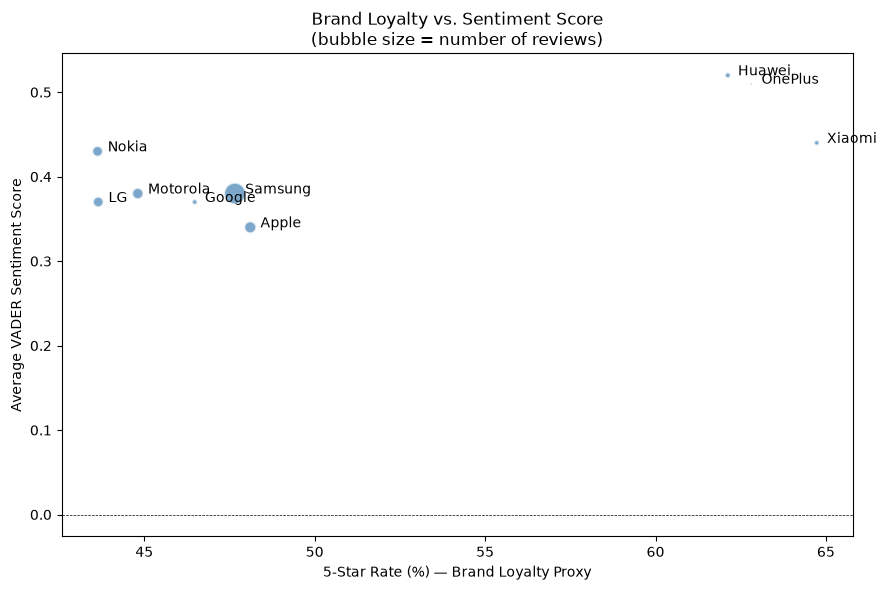

In [5]:
loyalty = df.groupby('brand').agg(
    total_reviews=('rating', 'count'),
    five_star_pct=('rating', lambda x: (x == 5).mean() * 100),
    mean_vader=('vader_compound', 'mean'),
    mean_rating=('rating', 'mean')
).round(2)

loyalty = loyalty.sort_values('five_star_pct', ascending=False)
print("Brand loyalty proxy (5-star rate):")
print(loyalty)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    loyalty['five_star_pct'], loyalty['mean_vader'],
    s=loyalty['total_reviews'] / 200,
    alpha=0.7, color='steelblue', edgecolors='white', linewidths=1.5
)
for brand, row in loyalty.iterrows():
    ax.annotate(brand, (row['five_star_pct'] + 0.3, row['mean_vader']), fontsize=10)
ax.set_xlabel('5-Star Rate (%) — Brand Loyalty Proxy')
ax.set_ylabel('Average VADER Sentiment Score')
ax.set_title('Brand Loyalty vs. Sentiment Score\n(bubble size = number of reviews)', fontsize=12)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('/Users/vinhlam/PycharmProjects/smartphones-review-analyzer/reports/05_loyalty_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()